## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## Load & Clean Data

In [2]:
df = pd.read_csv('../data/raw/cs-training.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Clean
df = df.dropna(subset=['SeriousDlqin2yrs'])
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)
df = df[df['age'] > 18]
df = df[df['DebtRatio'] < 1]
df = df[df['RevolvingUtilizationOfUnsecuredLines'] <= 1]

print(f"Dataset: {df.shape}")
print(f"Default rate: {df['SeriousDlqin2yrs'].mean():.2%}")

Dataset: (112035, 11)
Default rate: 6.05%


## PD Model

In [3]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pd_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pd_pipeline.fit(X_train, y_train)
df['PD'] = pd_pipeline.predict_proba(X)[:, 1]

auc = roc_auc_score(y_test, pd_pipeline.predict_proba(X_test)[:, 1])
print(f"PD Model — AUC-ROC: {auc:.4f}")
print(f"\nPD Statistics:\n{df['PD'].describe().round(4)}")

PD Model — AUC-ROC: 0.7894

PD Statistics:
count    112035.0000
mean          0.3890
std           0.2138
min           0.0000
25%           0.2180
50%           0.3196
75%           0.5453
max           1.0000
Name: PD, dtype: float64


## LGD

LGD Statistics:
count    112035.0000
mean          0.4801
std           0.0224
min           0.4500
25%           0.4625
50%           0.4774
75%           0.4936
max           0.5500
Name: LGD, dtype: float64


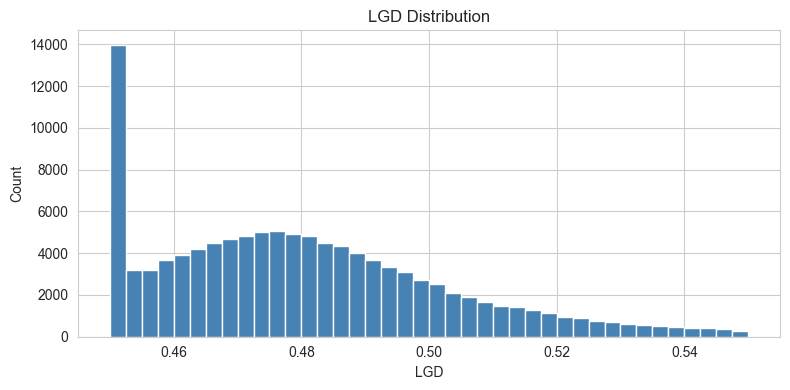

In [4]:
# LGD = estimated % of exposure lost if default occurs


def calculate_lgd(debt_ratio, base_lgd=0.45):
    """
    Estimates LGD based on debt ratio.
    Regulatory floor: 45% (Basel III unsecured retail)
    """
    lgd = base_lgd + (debt_ratio * 0.10)
    return np.clip(lgd, 0.45, 0.90)

df['LGD'] = df['DebtRatio'].apply(calculate_lgd)

print("LGD Statistics:")
print(df['LGD'].describe().round(4))

plt.figure(figsize=(8, 4))
df['LGD'].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('LGD Distribution')
plt.xlabel('LGD')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/lgd_distribution.png', dpi=150)
plt.show()

## EAD

In [5]:
# EAD = estimated outstanding balance at time of default


ASSUMED_CREDIT_LIMIT = 10000  # USD

df['EAD'] = df['RevolvingUtilizationOfUnsecuredLines'] * ASSUMED_CREDIT_LIMIT
df['EAD'] = df['EAD'].clip(lower=100, upper=50000)

print("EAD Statistics (USD):")
print(df['EAD'].describe().round(2))

EAD Statistics (USD):
count    112035.00
mean       3143.09
std        3371.46
min         100.00
25%         315.95
50%        1613.08
75%        5371.31
max       10000.00
Name: EAD, dtype: float64


## ECL Calculation

In [6]:
# ECL = PD × LGD × EAD
df['ECL'] = df['PD'] * df['LGD'] * df['EAD']

print("ECL Statistics (USD):")
print(df['ECL'].describe().round(2))
print(f"\nTotal Portfolio ECL: ${df['ECL'].sum():,.0f}")
print(f"Average ECL per customer: ${df['ECL'].mean():,.2f}")
print(f"ECL as % of total exposure: {(df['ECL'].sum() / df['EAD'].sum()):.2%}")

ECL Statistics (USD):
count    112035.00
mean        914.43
std        1246.35
min           0.00
25%          30.13
50%         231.50
75%        1411.68
max        5315.64
Name: ECL, dtype: float64

Total Portfolio ECL: $102,448,216
Average ECL per customer: $914.43
ECL as % of total exposure: 29.09%


## IFRS9 Staging

In [7]:

def assign_stage(pd_value):
    if pd_value < 0.05:
        return 'Stage 1 — Performing'
    elif pd_value < 0.20:
        return 'Stage 2 — Underperforming'
    else:
        return 'Stage 3 — Non-Performing'

df['Stage'] = df['PD'].apply(assign_stage)

stage_summary = df.groupby('Stage').agg(
    Customers=('PD', 'count'),
    Avg_PD=('PD', 'mean'),
    Avg_LGD=('LGD', 'mean'),
    Avg_EAD=('EAD', 'mean'),
    Total_ECL=('ECL', 'sum')
).round(2)

stage_summary['ECL_%'] = (stage_summary['Total_ECL'] /
                           stage_summary['Total_ECL'].sum() * 100).round(1)
print(stage_summary)

                           Customers  Avg_PD  Avg_LGD  Avg_EAD     Total_ECL  \
Stage                                                                          
Stage 1 — Performing              89    0.02     0.45  1108.36  7.146000e+02   
Stage 2 — Underperforming      22328    0.16     0.46   364.57  6.173705e+05   
Stage 3 — Non-Performing       89618    0.45     0.48  3837.37  1.018301e+08   

                           ECL_%  
Stage                             
Stage 1 — Performing         0.0  
Stage 2 — Underperforming    0.6  
Stage 3 — Non-Performing    99.4  


## Visualizations

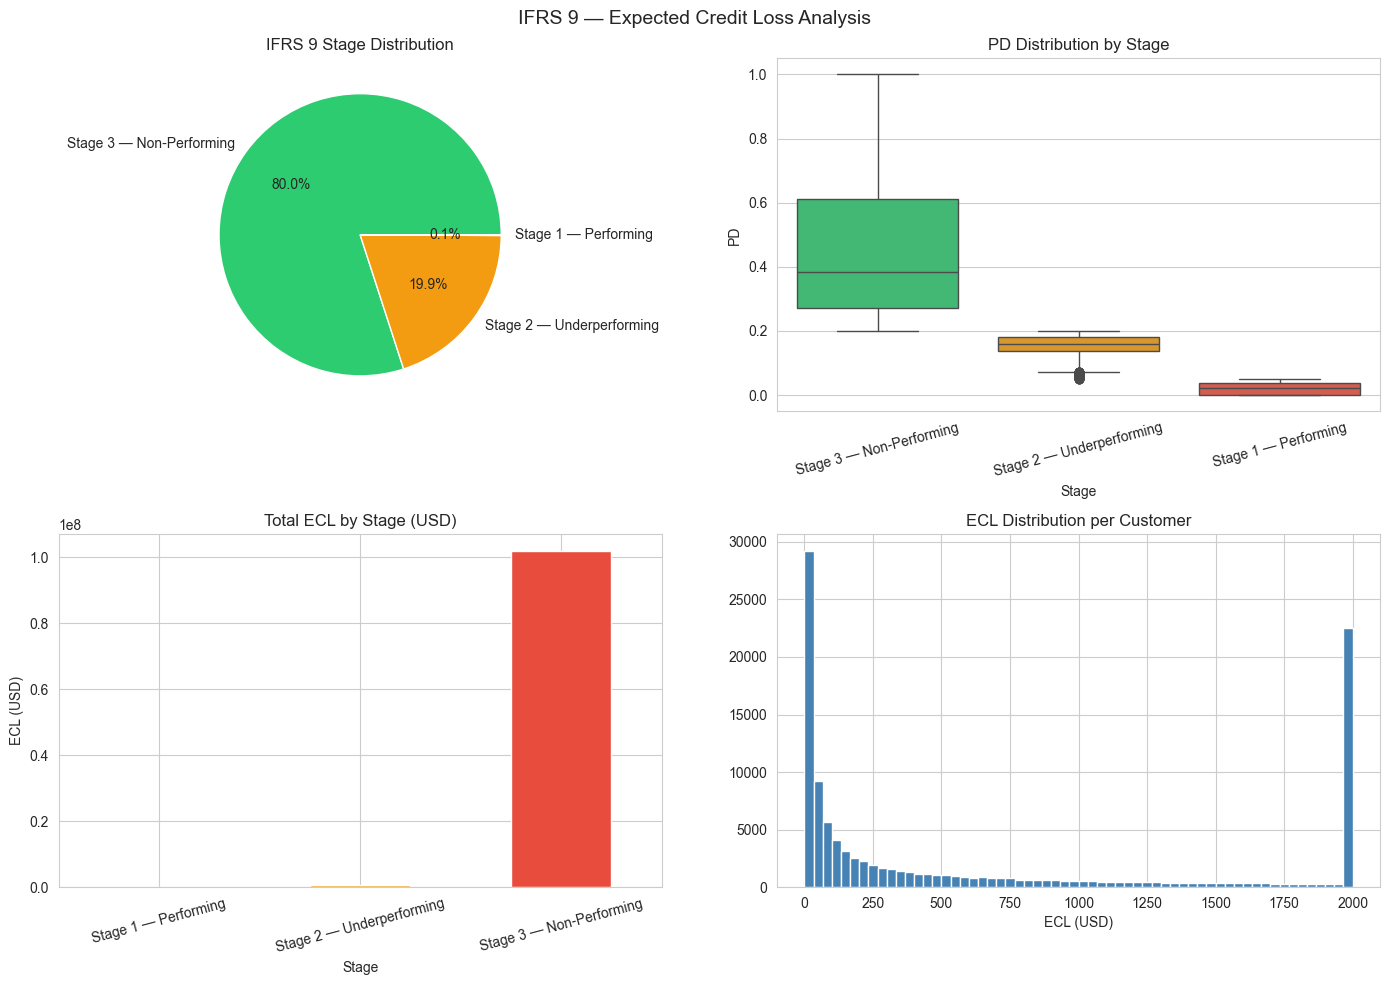

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Stage distribution
stage_counts = df['Stage'].value_counts()
axes[0,0].pie(stage_counts, labels=stage_counts.index,
              autopct='%1.1f%%', colors=['#2ECC71','#F39C12','#E74C3C'])
axes[0,0].set_title('IFRS 9 Stage Distribution')

# PD distribution by stage
sns.boxplot(data=df, x='Stage', y='PD', ax=axes[0,1],
            palette=['#2ECC71','#F39C12','#E74C3C'])
axes[0,1].set_title('PD Distribution by Stage')
axes[0,1].tick_params(axis='x', rotation=15)

# ECL by stage
stage_ecl = df.groupby('Stage')['ECL'].sum()
stage_ecl.plot(kind='bar', ax=axes[1,0],
               color=['#2ECC71','#F39C12','#E74C3C'], edgecolor='white')
axes[1,0].set_title('Total ECL by Stage (USD)')
axes[1,0].set_ylabel('ECL (USD)')
axes[1,0].tick_params(axis='x', rotation=15)

# ECL distribution
df['ECL'].clip(upper=2000).hist(bins=60, ax=axes[1,1],
                                 color='steelblue', edgecolor='white')
axes[1,1].set_title('ECL Distribution per Customer')
axes[1,1].set_xlabel('ECL (USD)')

plt.suptitle('IFRS 9 — Expected Credit Loss Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/ecl_analysis.png', dpi=150)
plt.show()

## Export Results

In [9]:
output = df[['PD', 'LGD', 'EAD', 'ECL', 'Stage']].copy()
output.to_csv('../data/processed/ecl_results.csv', index=False)

print("✅ ECL results saved to data/processed/ecl_results.csv")
print(f"\n{'='*45}")
print(f"  IFRS 9 ECL — Portfolio Summary")
print(f"{'='*45}")
print(f"  Total customers       : {len(df):,}")
print(f"  Total exposure (EAD)  : ${df['EAD'].sum():,.0f}")
print(f"  Total ECL             : ${df['ECL'].sum():,.0f}")
print(f"  ECL coverage ratio    : {(df['ECL'].sum()/df['EAD'].sum()):.2%}")
print(f"  PD Model AUC          : {auc:.4f}")
print(f"{'='*45}")

✅ ECL results saved to data/processed/ecl_results.csv

  IFRS 9 ECL — Portfolio Summary
  Total customers       : 112,035
  Total exposure (EAD)  : $352,136,585
  Total ECL             : $102,448,216
  ECL coverage ratio    : 29.09%
  PD Model AUC          : 0.7894
